1 — Load the dataset and understand the customer attributes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(df.head())
print(df.shape)
print(df.columns)
print(df.info())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

Check missing values:

In [2]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


2 — Identify relevant input features

In [3]:
df = df.drop('customerID', axis=1)

In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [5]:
print(df.isnull().sum())

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [6]:
df = df.dropna()

3 — Prepare the target variable

In [7]:
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

In [8]:
print(df['Churn'].value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


4 — Convert categorical features into numbers

In [9]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [10]:
X = pd.get_dummies(X, drop_first=True)

In [11]:
print(X.head())

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              0       1           29.85         29.85        False   
1              0      34           56.95       1889.50         True   
2              0       2           53.85        108.15         True   
3              0      45           42.30       1840.75         True   
4              0       2           70.70        151.65        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  MultipleLines_Yes  ...  \
0                            True              False  ...   
1                           False              False  ...   
2                           False              False  ...   
3               

5 — Split the data into training and testing data

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5625, 30)
Testing data: (1407, 30)


6 — Build the churn prediction model
We'll use Logistic Regression.

In [14]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


c:\Users\Rachana chowdary\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


7 — Predict churn for unseen customers

In [15]:
y_pred = model.predict(X_test)

print(y_pred)

[0 1 0 ... 0 0 0]


8 — Predict the probability of churn

In [16]:
y_probability = model.predict_proba(X_test)[:, 1]

print(y_probability[:10])

[0.01851415 0.58406071 0.00448134 0.20400057 0.10721003 0.47940247
 0.0255693  0.16602934 0.67702957 0.01540137]


9 — Classify customers into Likely to Churn / Likely to Stay

In [17]:
churn_status = np.where(
    y_probability >= 0.5,
    "Likely to Churn",
    "Likely to Stay"
)

print(churn_status[:20])

['Likely to Stay' 'Likely to Churn' 'Likely to Stay' 'Likely to Stay'
 'Likely to Stay' 'Likely to Stay' 'Likely to Stay' 'Likely to Stay'
 'Likely to Churn' 'Likely to Stay' 'Likely to Churn' 'Likely to Stay'
 'Likely to Churn' 'Likely to Stay' 'Likely to Stay' 'Likely to Churn'
 'Likely to Churn' 'Likely to Churn' 'Likely to Stay' 'Likely to Stay']


In [18]:
results = pd.DataFrame({
    'Actual Churn': y_test.values,
    'Churn Probability': y_probability,
    'Prediction': churn_status
})

print(results.head(10))

   Actual Churn  Churn Probability       Prediction
0             0           0.018514   Likely to Stay
1             0           0.584061  Likely to Churn
2             0           0.004481   Likely to Stay
3             1           0.204001   Likely to Stay
4             0           0.107210   Likely to Stay
5             1           0.479402   Likely to Stay
6             0           0.025569   Likely to Stay
7             0           0.166029   Likely to Stay
8             1           0.677030  Likely to Churn
9             0           0.015401   Likely to Stay


10 — Evaluate the model

In [19]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.8017057569296375
Precision: 0.6417910447761194
Recall   : 0.5748663101604278
F1 Score : 0.6064880112834978


11 — Analyze correctly identified churn customers and misclassified customers

In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[913 120]
 [159 215]]


In [21]:
print("Confusion Matrix")
print("----------------")
print("True Negative :", cm[0, 0])
print("False Positive:", cm[0, 1])
print("False Negative:", cm[1, 0])
print("True Positive :", cm[1, 1])

Confusion Matrix
----------------
True Negative : 913
False Positive: 120
False Negative: 159
True Positive : 215


How many churn customers were correctly identified?

In [22]:
print("Correctly identified churn customers:", cm[1, 1])

Correctly identified churn customers: 215


How many non-churn customers were misclassified?

In [23]:
print("Non-churn customers misclassified:", cm[0, 1])

Non-churn customers misclassified: 120


12 — Display the confusion matrix visually

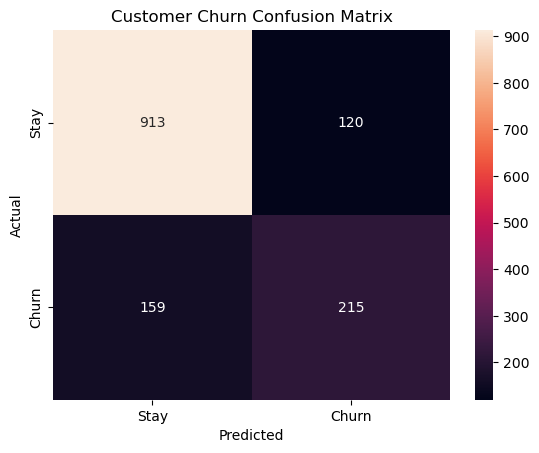

In [24]:
import seaborn as sns

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Stay', 'Churn'],
    yticklabels=['Stay', 'Churn']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Customer Churn Confusion Matrix")

plt.show()

13 — Interpret the results in business terms

Is it better to wrongly flag a loyal customer as churn? Or miss a customer who is actually going to leave?

It is generally more costly for the telecom company to miss a customer who is actually going to leave. A false negative means the company fails to identify a customer who is likely to churn, so it loses the opportunity to provide a retention offer.

14 — Suggest one improvement

Use class balancing and tune the classification threshold.

The dataset contains more customers who stayed than customers who churned. Therefore, using techniques such as class weighting or adjusting the probability threshold can help the model identify more actual churn customers.